# Churn Prediction Models
## Training Multiple Models for Customer Churn Prediction

This notebook trains and compares different machine learning models for predicting customer churn:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier
- Gradient Boosting Classifier
- Support Vector Machine (SVM)
- **Ensemble Models:**
  - Voting Classifier (Soft Voting)
  - Stacking Classifier

The models will be evaluated using:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Score
- Confusion Matrix
- Feature Importance Analysis
- Cross-Validation

**All trained models are automatically saved to the `models/` directory for future use.**

In [19]:
# Install required packages
!uv add scikit-learn xgboost matplotlib seaborn pandas numpy openpyxl

Resolved 54 packages in 25ms
Audited 47 packages in 33ms


In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Prepare Data

In [21]:
# Load the dataset
data_path = Path("customer_data_25000.xlsx")
df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


In [22]:
# Create binary churn target
# Churn = 1 if status is 'churned', else 0
df['churn'] = (df['status'] == 'churned').astype(int)

print("Churn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean():.2%}")
print(f"Non-Churn Rate: {(1 - df['churn'].mean()):.2%}")

Churn Distribution:
churn
0    22535
1     2339
Name: count, dtype: int64

Churn Rate: 9.40%
Non-Churn Rate: 90.60%


## 2. Feature Engineering and Selection

In [23]:
# Select features for modeling
# Numerical features
numerical_features = [
    'arr', 'mrr', 'health_score', 'risk_score', 'relationship_score',
    'churn_probability', 'sentiment_score', 'licenses_total', 
    'licenses_used', 'utilization_percentage'
]

# Categorical features
categorical_features = ['industry', 'company_size']

# Check which features exist in the dataset
available_numerical = [f for f in numerical_features if f in df.columns]
available_categorical = [f for f in categorical_features if f in df.columns]

print("Available Numerical Features:")
print(available_numerical)
print(f"\nAvailable Categorical Features:")
print(available_categorical)

# Create feature dataframe
feature_df = df[available_numerical + available_categorical + ['churn']].copy()

# Handle missing values
print(f"\nMissing values before imputation:")
print(feature_df.isnull().sum())

# Fill missing values in numerical columns with median
for col in available_numerical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].median(), inplace=True)

# Fill missing values in categorical columns with mode
for col in available_categorical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].mode()[0], inplace=True)

print(f"\nMissing values after imputation:")
print(feature_df.isnull().sum().sum())

Available Numerical Features:
['arr', 'mrr', 'health_score', 'risk_score', 'relationship_score', 'churn_probability', 'sentiment_score', 'licenses_total', 'licenses_used', 'utilization_percentage']

Available Categorical Features:
['industry', 'company_size']

Missing values before imputation:
arr                       0
mrr                       0
health_score              0
risk_score                0
relationship_score        0
churn_probability         0
sentiment_score           0
licenses_total            0
licenses_used             0
utilization_percentage    0
industry                  0
company_size              0
churn                     0
dtype: int64

Missing values after imputation:
0


In [24]:
# Encode categorical variables
label_encoders = {}
feature_df_encoded = feature_df.copy()

for col in available_categorical:
    le = LabelEncoder()
    feature_df_encoded[col] = le.fit_transform(feature_df[col].astype(str))
    label_encoders[col] = le
    print(f"{col} encoded: {len(le.classes_)} unique values")

# Prepare X and y
X = feature_df_encoded.drop('churn', axis=1)
y = feature_df_encoded['churn']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

industry encoded: 16 unique values
company_size encoded: 4 unique values

Feature matrix shape: (24874, 12)
Target distribution:
churn
0    22535
1     2339
Name: count, dtype: int64


In [25]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")

# Scale features for models that require scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Training set: 19,899 samples
Test set: 4,975 samples

Training set churn rate: 9.40%
Test set churn rate: 9.41%


## 3. Hyperparameter Tuning (Optional)

**Note:** This section performs hyperparameter tuning using RandomizedSearchCV. It may take several minutes to complete. You can skip this section and use default parameters, or set `ENABLE_TUNING = False` below.

In [26]:
# Import hyperparameter tuning tools
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Set to True to enable hyperparameter tuning, False to use default parameters
ENABLE_TUNING = True  # Change to False to skip tuning and use default parameters

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'lbfgs']
    }
}

# Store tuned models
tuned_models = {}

if ENABLE_TUNING:
    print("Starting Hyperparameter Tuning...")
    print("=" * 80)
    print("This may take several minutes. Please be patient...\n")
    
    # Tune Random Forest
    print("Tuning Random Forest...")
    rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_search = RandomizedSearchCV(
        rf_base, param_grids['Random Forest'],
        n_iter=20,  # Number of parameter settings sampled
        cv=3,  # 3-fold CV for faster tuning
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    rf_search.fit(X_train, y_train)
    tuned_models['Random Forest'] = rf_search.best_estimator_
    print(f"  Best Score: {rf_search.best_score_:.4f}")
    print(f"  Best Params: {rf_search.best_params_}\n")
    
    # Tune XGBoost
    print("Tuning XGBoost...")
    xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_search = RandomizedSearchCV(
        xgb_base, param_grids['XGBoost'],
        n_iter=20,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    xgb_search.fit(X_train, y_train)
    tuned_models['XGBoost'] = xgb_search.best_estimator_
    print(f"  Best Score: {xgb_search.best_score_:.4f}")
    print(f"  Best Params: {xgb_search.best_params_}\n")
    
    # Tune Gradient Boosting
    print("Tuning Gradient Boosting...")
    gb_base = GradientBoostingClassifier(random_state=42)
    gb_search = RandomizedSearchCV(
        gb_base, param_grids['Gradient Boosting'],
        n_iter=20,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    gb_search.fit(X_train, y_train)
    tuned_models['Gradient Boosting'] = gb_search.best_estimator_
    print(f"  Best Score: {gb_search.best_score_:.4f}")
    print(f"  Best Params: {gb_search.best_params_}\n")
    
    # Tune Logistic Regression
    print("Tuning Logistic Regression...")
    lr_base = LogisticRegression(random_state=42, max_iter=1000)
    lr_search = RandomizedSearchCV(
        lr_base, param_grids['Logistic Regression'],
        n_iter=15,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    lr_search.fit(X_train_scaled, y_train)
    tuned_models['Logistic Regression'] = lr_search.best_estimator_
    print(f"  Best Score: {lr_search.best_score_:.4f}")
    print(f"  Best Params: {lr_search.best_params_}\n")
    
    print("=" * 80)
    print("Hyperparameter tuning completed! ✓")
    print("=" * 80)
else:
    print("Hyperparameter tuning is disabled. Using default parameters.")
    print("Set ENABLE_TUNING = True to enable tuning.")

Starting Hyperparameter Tuning...
This may take several minutes. Please be patient...

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 0.9490
  Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 0.9485
  Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 0.9490
  Best Params: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 7, 'learning_rate': 0.2}

Tuning Logistic Regression...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Best Score: 0.9404
  Best Params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}

Hyperparameter tuning completed! ✓


## 4. Model Training and Evaluation

In [27]:
# Initialize models - use tuned models if available, otherwise use defaults
models = {}

if ENABLE_TUNING and len(tuned_models) > 0:
    # Use tuned models
    models['Logistic Regression'] = tuned_models.get('Logistic Regression', 
        LogisticRegression(random_state=42, max_iter=1000))
    models['Random Forest'] = tuned_models.get('Random Forest',
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    models['XGBoost'] = tuned_models.get('XGBoost',
        xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
    models['Gradient Boosting'] = tuned_models.get('Gradient Boosting',
        GradientBoostingClassifier(random_state=42))
    print("Using tuned hyperparameters for models where available.")
else:
    # Use default models
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    }
    print("Using default hyperparameters.")

# Add SVM (not tuned due to computational cost)
models['SVM'] = SVC(probability=True, random_state=42)

# Store results
results = {}
predictions = {}
probabilities = {}

print("Training models...")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled features for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

print("\n" + "=" * 80)
print("All models trained successfully!")

Using tuned hyperparameters for models where available.
Training models...

Training Logistic Regression...
  Accuracy: 0.9029
  Precision: 0.4672
  Recall: 0.2286
  F1-Score: 0.3070
  ROC-AUC: 0.9378

Training Random Forest...
  Accuracy: 0.9055
  Precision: 0.4972
  Recall: 0.3825
  F1-Score: 0.4324
  ROC-AUC: 0.9458

Training XGBoost...
  Accuracy: 0.9021
  Precision: 0.3855
  Recall: 0.0684
  F1-Score: 0.1162
  ROC-AUC: 0.9451

Training Gradient Boosting...
  Accuracy: 0.9059
  Precision: 0.5000
  Recall: 0.4551
  F1-Score: 0.4765
  ROC-AUC: 0.9450

Training SVM...
  Accuracy: 0.9059
  Precision: 0.5000
  Recall: 0.0833
  F1-Score: 0.1429
  ROC-AUC: 0.9302

All models trained successfully!


Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.9055     0.4972  0.3825    0.4324   0.9458
XGBoost                0.9021     0.3855  0.0684    0.1162   0.9451
Gradient Boosting      0.9059     0.5000  0.4551    0.4765   0.9450
Logistic Regression    0.9029     0.4672  0.2286    0.3070   0.9378
SVM                    0.9059     0.5000  0.0833    0.1429   0.9302


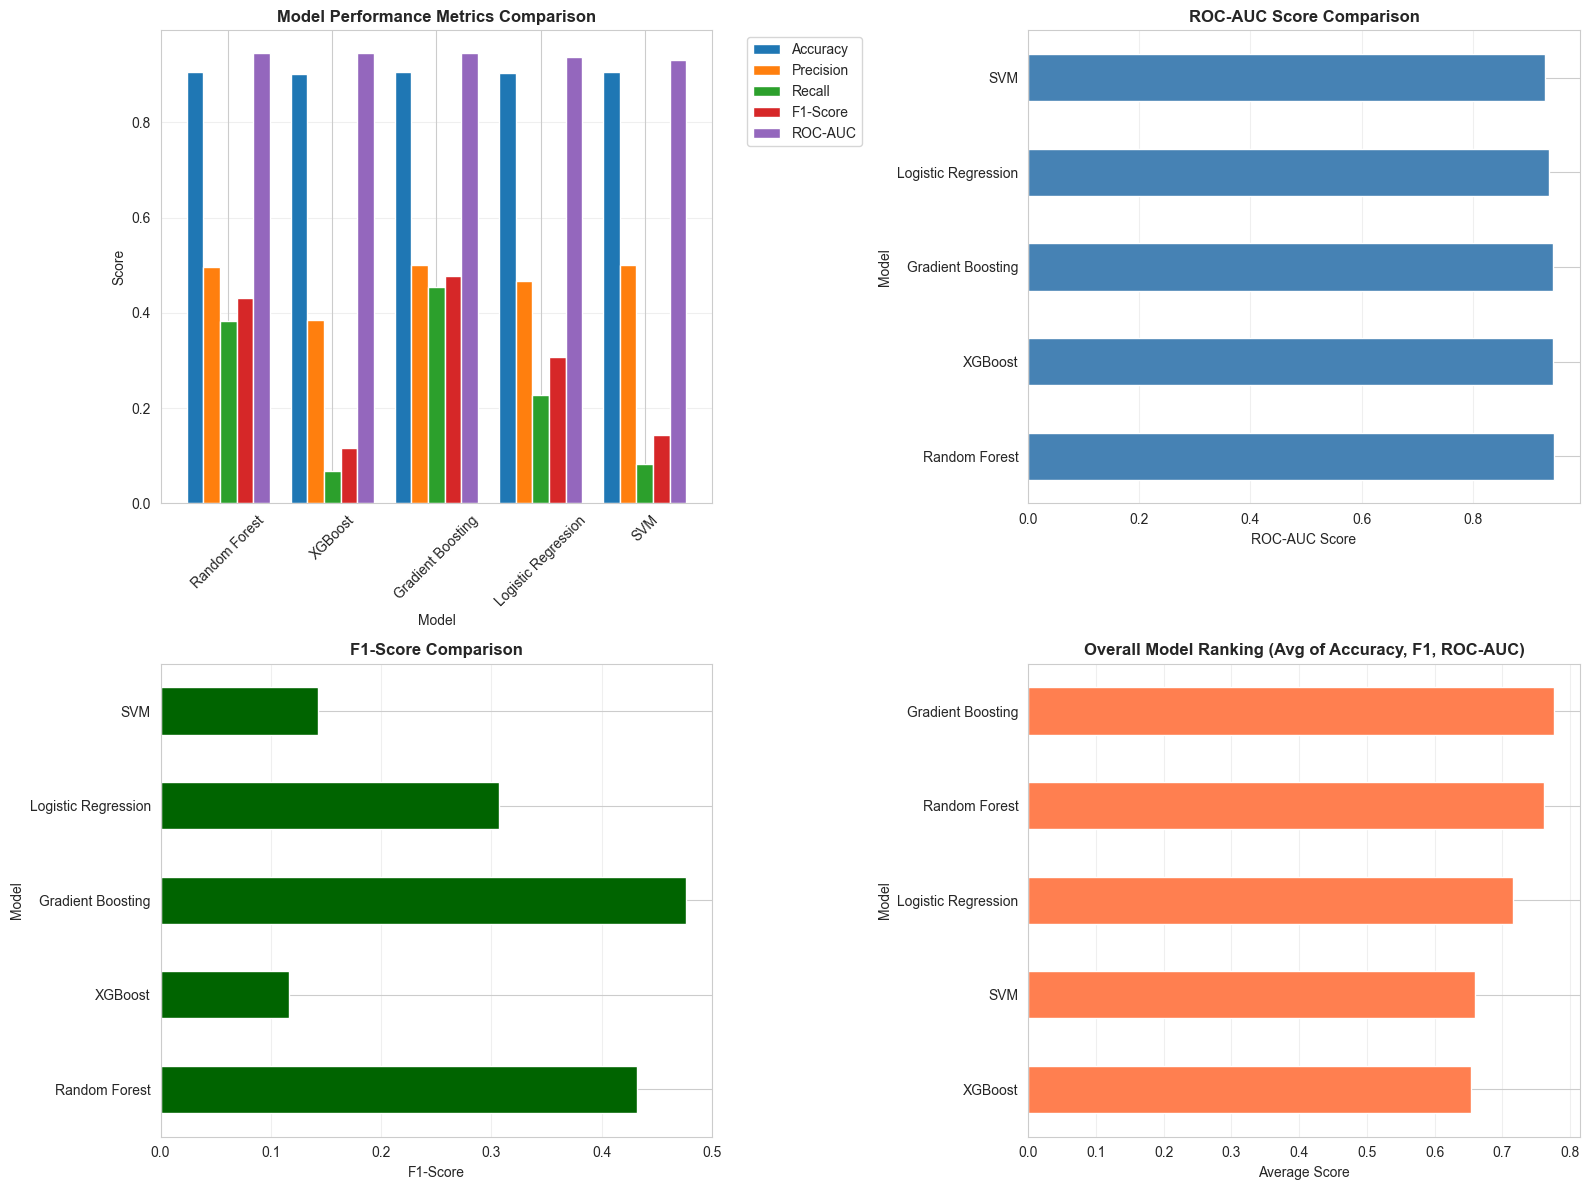

In [28]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("Model Performance Comparison:")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df[metrics].plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Model Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=10)
axes[0, 0].set_xlabel('Model', fontsize=10)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# ROC-AUC comparison
results_df['ROC-AUC'].plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('ROC-AUC Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# F1-Score comparison
results_df['F1-Score'].plot(kind='barh', ax=axes[1, 0], color='darkgreen')
axes[1, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('F1-Score', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking
overall_score = (results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']) / 3
overall_score.sort_values(ascending=True).plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Overall Model Ranking (Avg of Accuracy, F1, ROC-AUC)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. ROC Curves

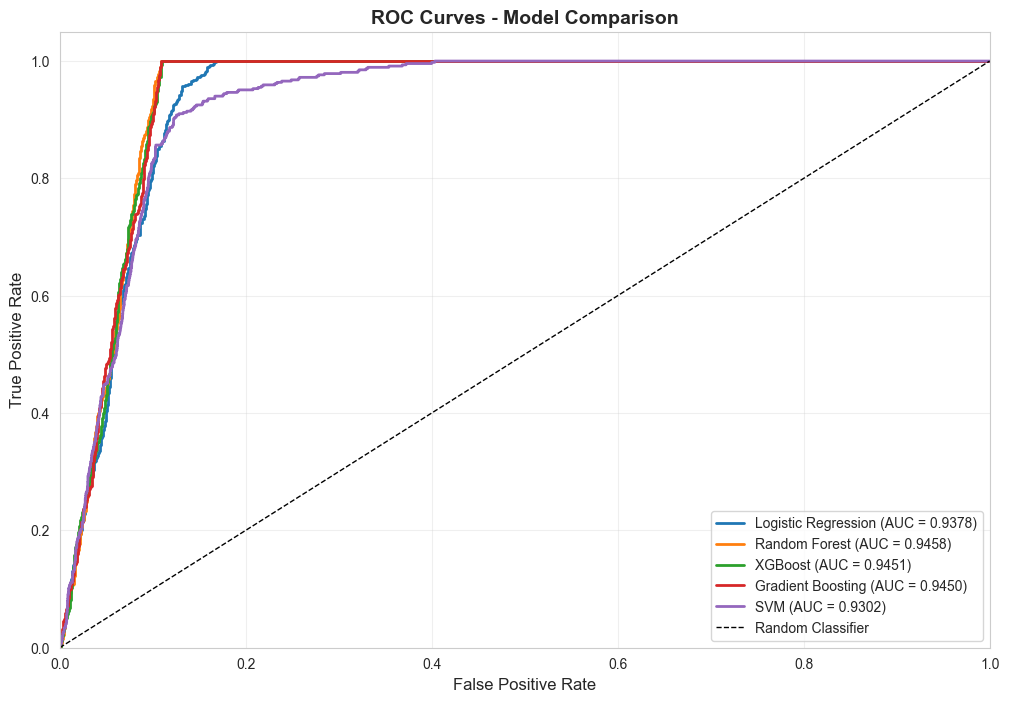

In [29]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 5. Confusion Matrices

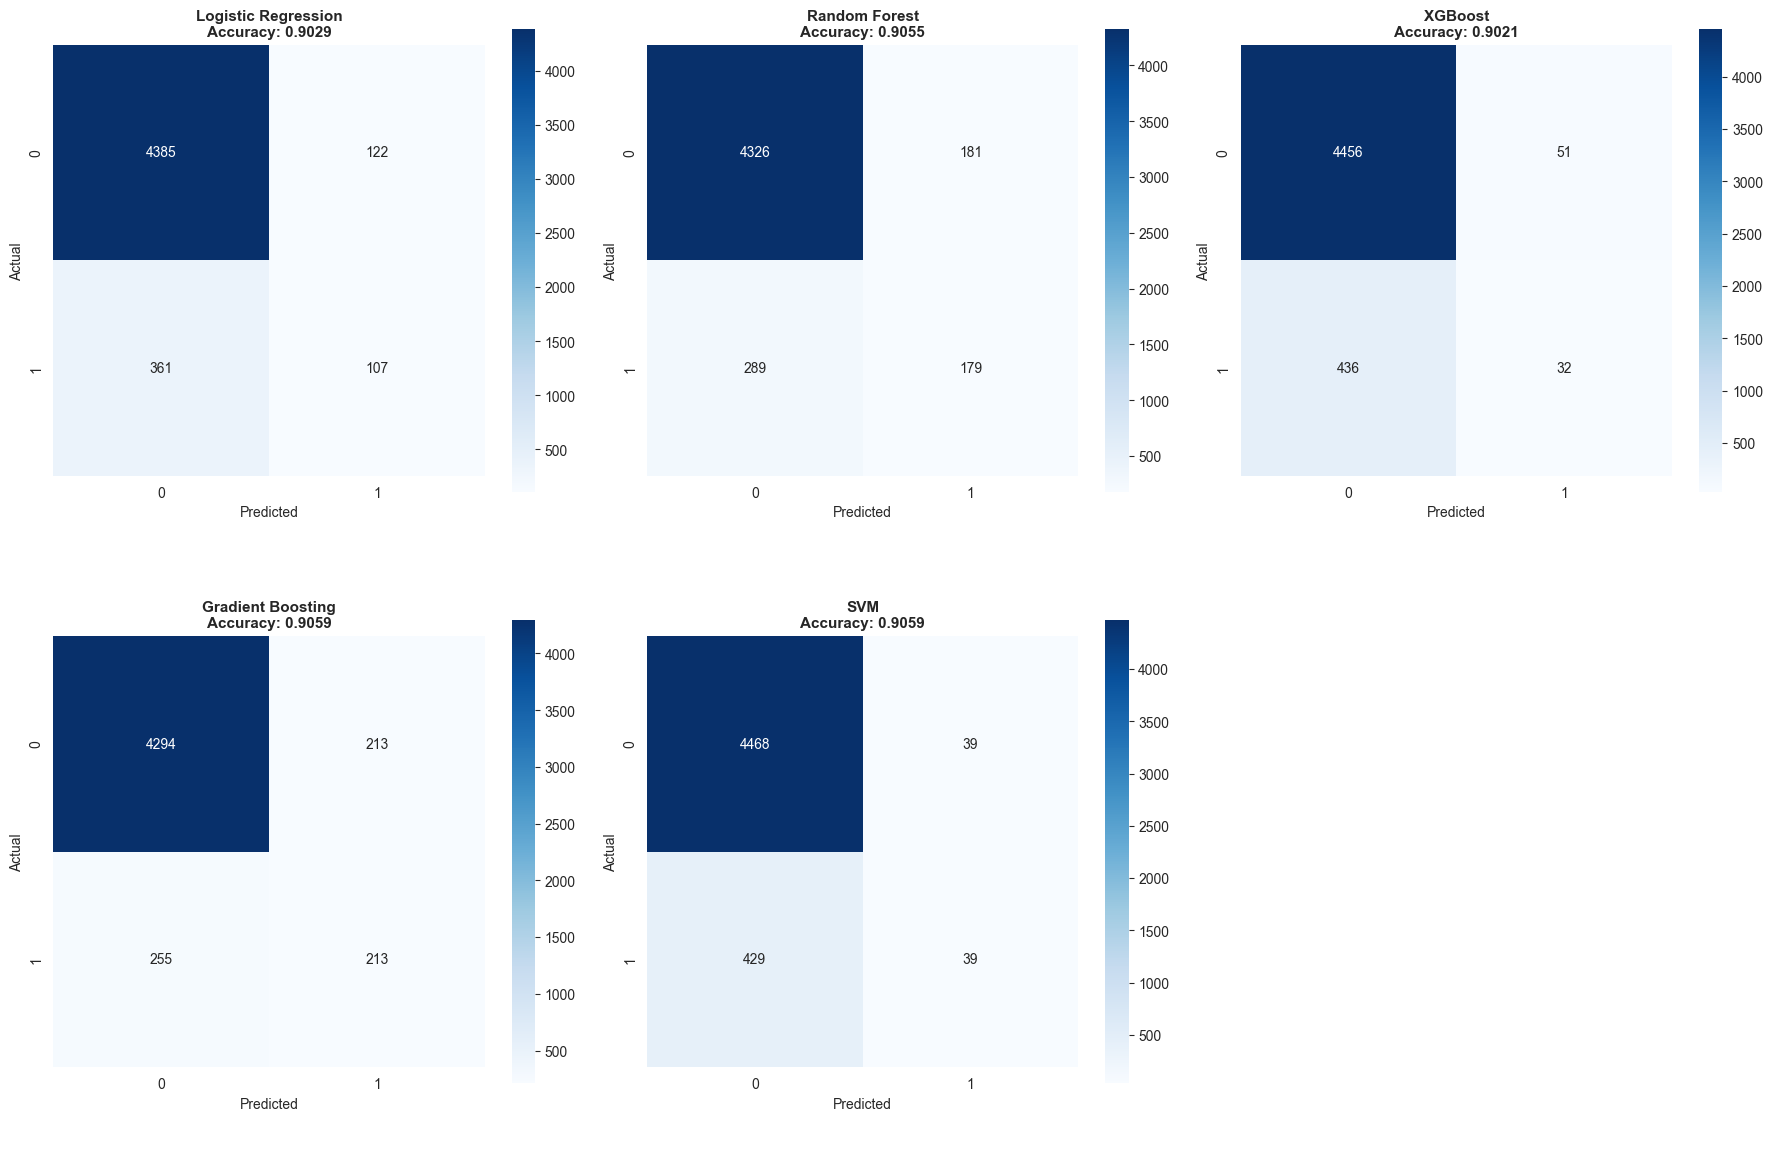

In [30]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'shrink': 0.8}, square=True)
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.4f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

# Hide the last subplot if odd number of models
if len(models) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

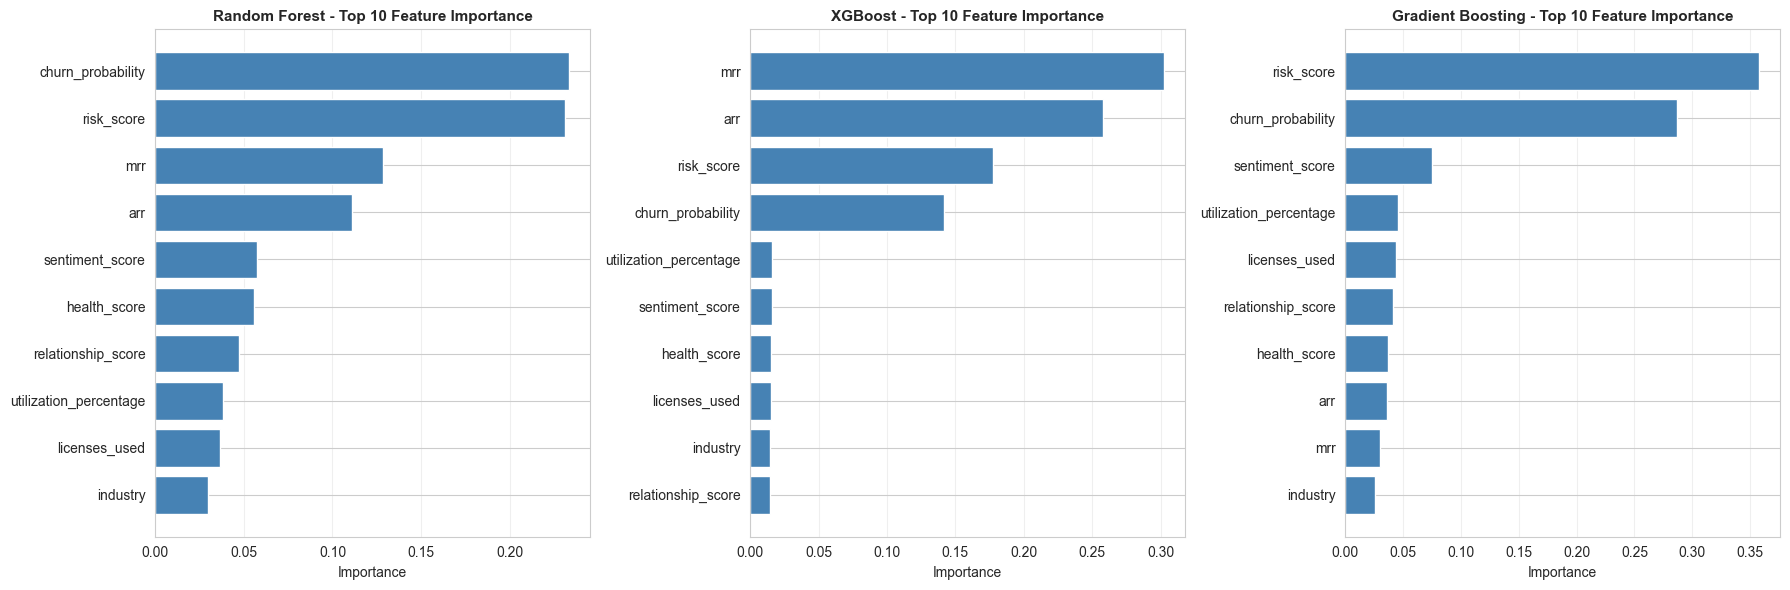


Random Forest - Feature Importance:
               Feature  Importance
     churn_probability    0.233548
            risk_score    0.231348
                   mrr    0.128423
                   arr    0.111123
       sentiment_score    0.057236
          health_score    0.055877
    relationship_score    0.047367
utilization_percentage    0.038331
         licenses_used    0.036665
              industry    0.029704
        licenses_total    0.016114
          company_size    0.014265


XGBoost - Feature Importance:
               Feature  Importance
                   mrr    0.302715
                   arr    0.257981
            risk_score    0.177819
     churn_probability    0.141417
utilization_percentage    0.016183
       sentiment_score    0.015947
          health_score    0.015302
         licenses_used    0.015258
              industry    0.014903
    relationship_score    0.014680
        licenses_total    0.014172
          company_size    0.013625


Gradient Boosting -

In [31]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']

fig, axes = plt.subplots(1, len(tree_models), figsize=(18, 6))
if len(tree_models) == 1:
    axes = [axes]

for idx, name in enumerate(tree_models):
    model = models[name]
    
    # Get feature importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_names = X.columns
        
        # Create DataFrame and sort
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        # Plot top 10 features
        top_features = importance_df.head(10)
        axes[idx].barh(range(len(top_features)), top_features['importance'], color='steelblue')
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features['feature'])
        axes[idx].set_xlabel('Importance', fontsize=10)
        axes[idx].set_title(f'{name} - Top 10 Feature Importance', 
                           fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='x')
        axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

# Display feature importance tables
for name in tree_models:
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print(f"\n{name} - Feature Importance:")
        print("=" * 60)
        print(importance_df.to_string(index=False))
        print()

In [32]:
# Perform cross-validation for more robust evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Performing 5-Fold Cross-Validation...")
print("=" * 80)

for name, model in models.items():
    print(f"\n{name}...")
    
    # Use scaled features for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        X_cv = X_train_scaled.values
    else:
        X_cv = X_train.values
    
    # Cross-validation scores
    cv_accuracy = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_roc_auc = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    cv_results[name] = {
        'CV Accuracy Mean': cv_accuracy.mean(),
        'CV Accuracy Std': cv_accuracy.std(),
        'CV F1 Mean': cv_f1.mean(),
        'CV F1 Std': cv_f1.std(),
        'CV ROC-AUC Mean': cv_roc_auc.mean(),
        'CV ROC-AUC Std': cv_roc_auc.std()
    }
    
    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
    print(f"  CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")
    print(f"  CV ROC-AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std() * 2:.4f})")

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results).T
print("\n" + "=" * 80)
print("Cross-Validation Results Summary:")
print(cv_results_df.round(4))

Performing 5-Fold Cross-Validation...

Logistic Regression...
  CV Accuracy: 0.9057 (+/- 0.0045)
  CV F1-Score: 0.3231 (+/- 0.0470)
  CV ROC-AUC: 0.9405 (+/- 0.0070)

Random Forest...
  CV Accuracy: 0.9075 (+/- 0.0073)
  CV F1-Score: 0.4487 (+/- 0.0228)
  CV ROC-AUC: 0.9484 (+/- 0.0086)

XGBoost...
  CV Accuracy: 0.9056 (+/- 0.0061)
  CV F1-Score: 0.1895 (+/- 0.0575)
  CV ROC-AUC: 0.9476 (+/- 0.0086)

Gradient Boosting...
  CV Accuracy: 0.9051 (+/- 0.0083)
  CV F1-Score: 0.4849 (+/- 0.0266)
  CV ROC-AUC: 0.9469 (+/- 0.0077)

SVM...
  CV Accuracy: 0.9064 (+/- 0.0046)
  CV F1-Score: 0.1627 (+/- 0.0959)
  CV ROC-AUC: 0.9312 (+/- 0.0077)

Cross-Validation Results Summary:
                     CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  \
Logistic Regression            0.9057           0.0022      0.3231     0.0235   
Random Forest                  0.9075           0.0037      0.4487     0.0114   
XGBoost                        0.9056           0.0030      0.1895     0.0288   

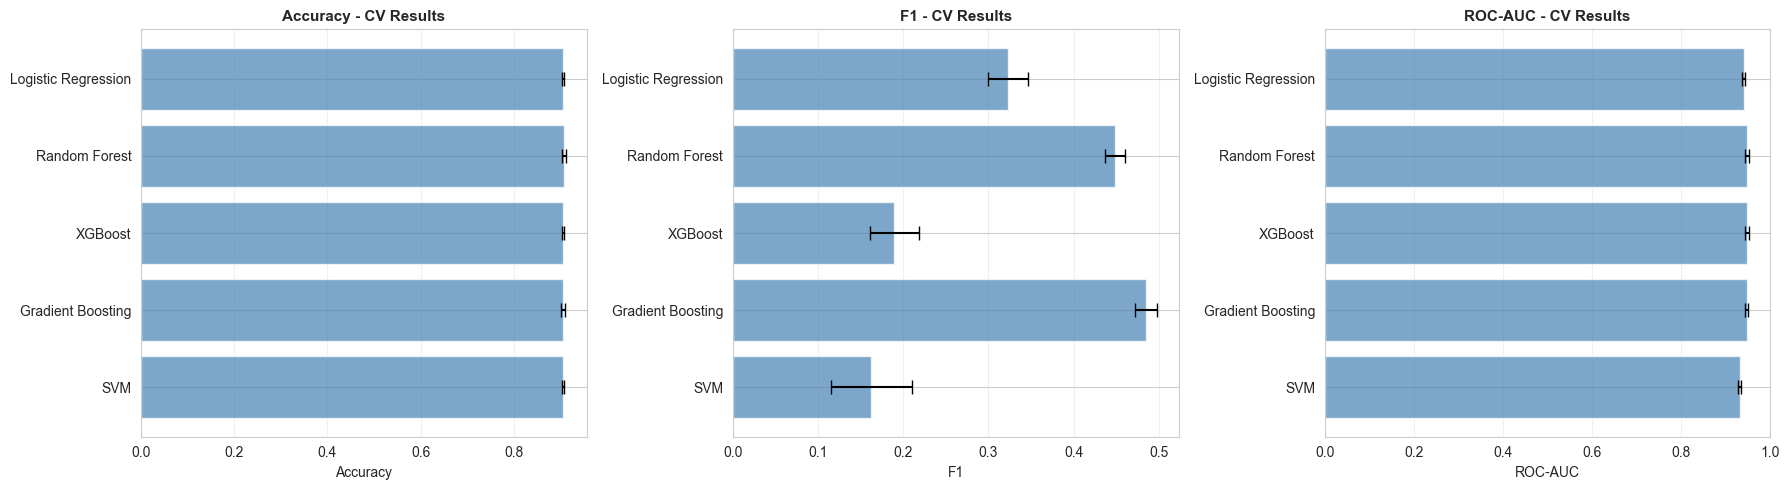

In [33]:
# Visualize cross-validation results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_cv = ['CV Accuracy Mean', 'CV F1 Mean', 'CV ROC-AUC Mean']
stds_cv = ['CV Accuracy Std', 'CV F1 Std', 'CV ROC-AUC Std']

for idx, (metric, std) in enumerate(zip(metrics_cv, stds_cv)):
    means = cv_results_df[metric]
    stds = cv_results_df[std]
    
    axes[idx].barh(range(len(means)), means, xerr=stds, color='steelblue', 
                   capsize=5, alpha=0.7)
    axes[idx].set_yticks(range(len(means)))
    axes[idx].set_yticklabels(means.index)
    axes[idx].set_xlabel(metric.replace('CV ', '').replace(' Mean', ''), fontsize=10)
    axes[idx].set_title(f'{metric.replace("CV ", "").replace(" Mean", "")} - CV Results', 
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Detailed Classification Reports

## 10. Making Predictions on New Data

This section demonstrates how to use the trained models to make predictions on new, unseen data.

In [35]:
# Example: Making predictions on new data using the best model
# This demonstrates the complete prediction pipeline

print("=" * 80)
print("PREDICTION PIPELINE - Using Best Model")
print("=" * 80)

# Calculate Overall Score if it doesn't exist
if 'Overall Score' not in results_df.columns:
    results_df['Overall Score'] = (
        results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']
    ) / 3

# Get the best model
best_model_name = results_df['Overall Score'].idxmax()
best_model = models.get(best_model_name)

if best_model_name in ['Logistic Regression', 'SVM']:
    best_model_scaled = True
    X_for_prediction = X_test_scaled
else:
    best_model_scaled = False
    X_for_prediction = X_test

print(f"\nUsing Best Model: {best_model_name}")
print(f"Model requires scaling: {best_model_scaled}")

# Make predictions on test set (as example of new data)
print(f"\nMaking predictions on {len(X_for_prediction)} samples...")

# Predictions
churn_predictions = best_model.predict(X_for_prediction)
churn_probabilities = best_model.predict_proba(X_for_prediction)[:, 1]

# Create prediction results DataFrame
prediction_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': churn_predictions,
    'Churn_Probability': churn_probabilities,
    'Prediction_Correct': (y_test.values == churn_predictions)
})

# Add risk categories based on probability
prediction_results['Risk_Level'] = pd.cut(
    prediction_results['Churn_Probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print(f"\nPrediction Summary:")
print("=" * 80)
print(f"Total predictions: {len(prediction_results)}")
print(f"Predicted Churn: {(churn_predictions == 1).sum()} ({(churn_predictions == 1).mean():.2%})")
print(f"Predicted No Churn: {(churn_predictions == 0).sum()} ({(churn_predictions == 0).mean():.2%})")
print(f"\nAccuracy: {prediction_results['Prediction_Correct'].mean():.4f}")

print(f"\nRisk Level Distribution:")
print(prediction_results['Risk_Level'].value_counts().sort_index())

# Show sample predictions
print(f"\nSample Predictions (First 10):")
print("=" * 80)
print(prediction_results[['Actual', 'Predicted', 'Churn_Probability', 'Risk_Level', 'Prediction_Correct']].head(10).to_string(index=False))

PREDICTION PIPELINE - Using Best Model

Using Best Model: Gradient Boosting
Model requires scaling: False

Making predictions on 4975 samples...

Prediction Summary:
Total predictions: 4975
Predicted Churn: 426 (8.56%)
Predicted No Churn: 4549 (91.44%)

Accuracy: 0.9059

Risk Level Distribution:
Risk_Level
Low         4265
Medium       284
High         260
Critical     166
Name: count, dtype: int64

Sample Predictions (First 10):
 Actual  Predicted  Churn_Probability Risk_Level  Prediction_Correct
      0          0           0.000204        Low                True
      0          0           0.000227        Low                True
      1          0           0.252754        Low               False
      0          0           0.000233        Low                True
      0          0           0.000227        Low                True
      0          0           0.000227        Low                True
      0          0           0.000191        Low                True
      0       

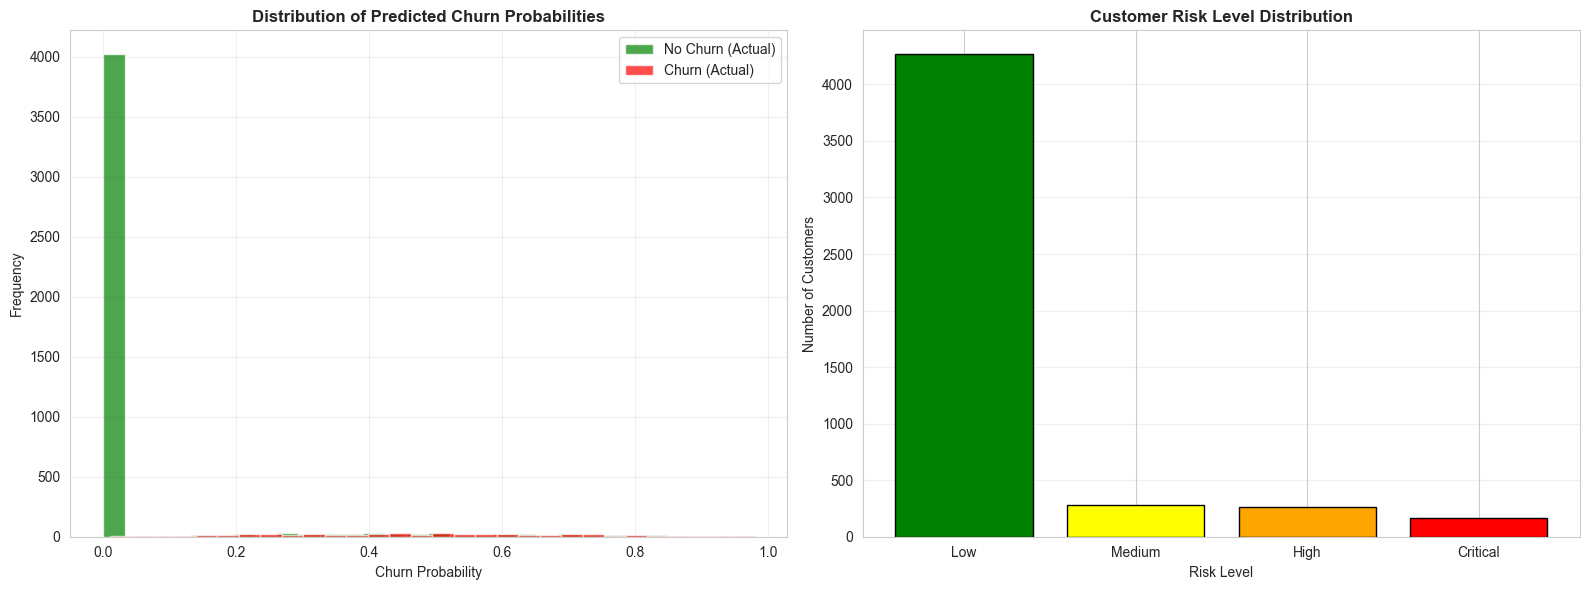


⚠️  High-Risk Customers (Churn Probability > 0.7): 166
   Average Churn Probability: 0.7967
   Actual Churn Rate: 45.78%


In [36]:
# Visualize prediction results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of churn probabilities
axes[0].hist(churn_probabilities[y_test == 0], bins=30, alpha=0.7, label='No Churn (Actual)', color='green')
axes[0].hist(churn_probabilities[y_test == 1], bins=30, alpha=0.7, label='Churn (Actual)', color='red')
axes[0].set_xlabel('Churn Probability', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Distribution of Predicted Churn Probabilities', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Risk level distribution
risk_counts = prediction_results['Risk_Level'].value_counts().sort_index()
colors = ['green', 'yellow', 'orange', 'red']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors[:len(risk_counts)], edgecolor='black')
axes[1].set_xlabel('Risk Level', fontsize=10)
axes[1].set_ylabel('Number of Customers', fontsize=10)
axes[1].set_title('Customer Risk Level Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# High-risk customers (probability > 0.7)
high_risk_customers = prediction_results[prediction_results['Churn_Probability'] > 0.7]
print(f"\n⚠️  High-Risk Customers (Churn Probability > 0.7): {len(high_risk_customers)}")
if len(high_risk_customers) > 0:
    print(f"   Average Churn Probability: {high_risk_customers['Churn_Probability'].mean():.4f}")
    print(f"   Actual Churn Rate: {high_risk_customers['Actual'].mean():.2%}")

In [37]:
# Print detailed classification reports for each model
for name, y_pred in predictions.items():
    print("=" * 80)
    print(f"{name} - Classification Report")
    print("=" * 80)
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print()

Logistic Regression - Classification Report
              precision    recall  f1-score   support

    No Churn       0.92      0.97      0.95      4507
       Churn       0.47      0.23      0.31       468

    accuracy                           0.90      4975
   macro avg       0.70      0.60      0.63      4975
weighted avg       0.88      0.90      0.89      4975


Random Forest - Classification Report
              precision    recall  f1-score   support

    No Churn       0.94      0.96      0.95      4507
       Churn       0.50      0.38      0.43       468

    accuracy                           0.91      4975
   macro avg       0.72      0.67      0.69      4975
weighted avg       0.90      0.91      0.90      4975


XGBoost - Classification Report
              precision    recall  f1-score   support

    No Churn       0.91      0.99      0.95      4507
       Churn       0.39      0.07      0.12       468

    accuracy                           0.90      4975
   macro avg

## 9. Model Summary and Recommendations

In [38]:
# Final summary
print("=" * 80)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 80)

# Best model by each metric
best_accuracy = results_df['Accuracy'].idxmax()
best_f1 = results_df['F1-Score'].idxmax()
best_roc_auc = results_df['ROC-AUC'].idxmax()

print(f"\n🏆 Best Model by Accuracy: {best_accuracy} ({results_df.loc[best_accuracy, 'Accuracy']:.4f})")
print(f"🏆 Best Model by F1-Score: {best_f1} ({results_df.loc[best_f1, 'F1-Score']:.4f})")
print(f"🏆 Best Model by ROC-AUC: {best_roc_auc} ({results_df.loc[best_roc_auc, 'ROC-AUC']:.4f})")

# Overall best model (average of key metrics)
results_df['Overall Score'] = (
    results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']
) / 3
best_overall = results_df['Overall Score'].idxmax()

print(f"\n⭐ Overall Best Model: {best_overall}")
print(f"   Accuracy: {results_df.loc[best_overall, 'Accuracy']:.4f}")
print(f"   F1-Score: {results_df.loc[best_overall, 'F1-Score']:.4f}")
print(f"   ROC-AUC: {results_df.loc[best_overall, 'ROC-AUC']:.4f}")
print(f"   Overall Score: {results_df.loc[best_overall, 'Overall Score']:.4f}")

print("\n" + "=" * 80)
print("Model Training Complete! 🎉")
print("=" * 80)

FINAL MODEL COMPARISON SUMMARY

🏆 Best Model by Accuracy: Gradient Boosting (0.9059)
🏆 Best Model by F1-Score: Gradient Boosting (0.4765)
🏆 Best Model by ROC-AUC: Random Forest (0.9458)

⭐ Overall Best Model: Gradient Boosting
   Accuracy: 0.9059
   F1-Score: 0.4765
   ROC-AUC: 0.9450
   Overall Score: 0.7758

Model Training Complete! 🎉


In [39]:
# Quick import check - run this if you get NameError
# This ensures VotingClassifier and StackingClassifier are imported
from sklearn.ensemble import VotingClassifier, StackingClassifier
print("Ensemble classifiers imported successfully!")

Ensemble classifiers imported successfully!


## 10. Ensemble Models

**Note:** Make sure you have run all previous cells, especially the import cell (Cell 2), before running this section.

In [40]:
# Verify imports are available
try:
    from sklearn.ensemble import VotingClassifier, StackingClassifier
    print("✓ Ensemble imports verified")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Please re-run Cell 2 (imports cell) before continuing.")
    raise

# Create base models for ensemble (using best performing models)
# We'll use models that don't require scaling for the ensemble
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
    ('gb', GradientBoostingClassifier(random_state=42))
]

# Create Voting Classifier (Soft Voting - uses probabilities)
voting_clf = VotingClassifier(
    estimators=base_models,
    voting='soft',  # Use soft voting for probability-based predictions
    n_jobs=-1
)

# Create Stacking Classifier (uses meta-learner)
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Train ensemble models
print("Training Ensemble Models...")
print("=" * 80)

# Train Voting Classifier
print("\nTraining Voting Classifier (Soft Voting)...")
voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)
voting_proba = voting_clf.predict_proba(X_test)[:, 1]

# Train Stacking Classifier
print("Training Stacking Classifier...")
stacking_clf.fit(X_train, y_train)
stacking_pred = stacking_clf.predict(X_test)
stacking_proba = stacking_clf.predict_proba(X_test)[:, 1]

# Calculate metrics for ensemble models
ensemble_results = {}

for name, y_pred, y_proba in [
    ('Voting Classifier', voting_pred, voting_proba),
    ('Stacking Classifier', stacking_pred, stacking_proba)
]:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    ensemble_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

# Add ensemble models to main results
results.update(ensemble_results)
predictions['Voting Classifier'] = voting_pred
predictions['Stacking Classifier'] = stacking_pred
probabilities['Voting Classifier'] = voting_proba
probabilities['Stacking Classifier'] = stacking_proba

print("\n" + "=" * 80)
print("Ensemble models trained successfully!")

✓ Ensemble imports verified
Training Ensemble Models...

Training Voting Classifier (Soft Voting)...
Training Stacking Classifier...

Voting Classifier:
  Accuracy: 0.9019
  Precision: 0.4755
  Recall: 0.4145
  F1-Score: 0.4429
  ROC-AUC: 0.9448

Stacking Classifier:
  Accuracy: 0.9071
  Precision: 0.5081
  Recall: 0.4038
  F1-Score: 0.4500
  ROC-AUC: 0.9465

Ensemble models trained successfully!


Updated Model Performance Comparison (Including Ensembles):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Stacking Classifier    0.9071     0.5081  0.4038    0.4500   0.9465
Random Forest          0.9055     0.4972  0.3825    0.4324   0.9458
XGBoost                0.9021     0.3855  0.0684    0.1162   0.9451
Gradient Boosting      0.9059     0.5000  0.4551    0.4765   0.9450
Voting Classifier      0.9019     0.4755  0.4145    0.4429   0.9448
Logistic Regression    0.9029     0.4672  0.2286    0.3070   0.9378
SVM                    0.9059     0.5000  0.0833    0.1429   0.9302


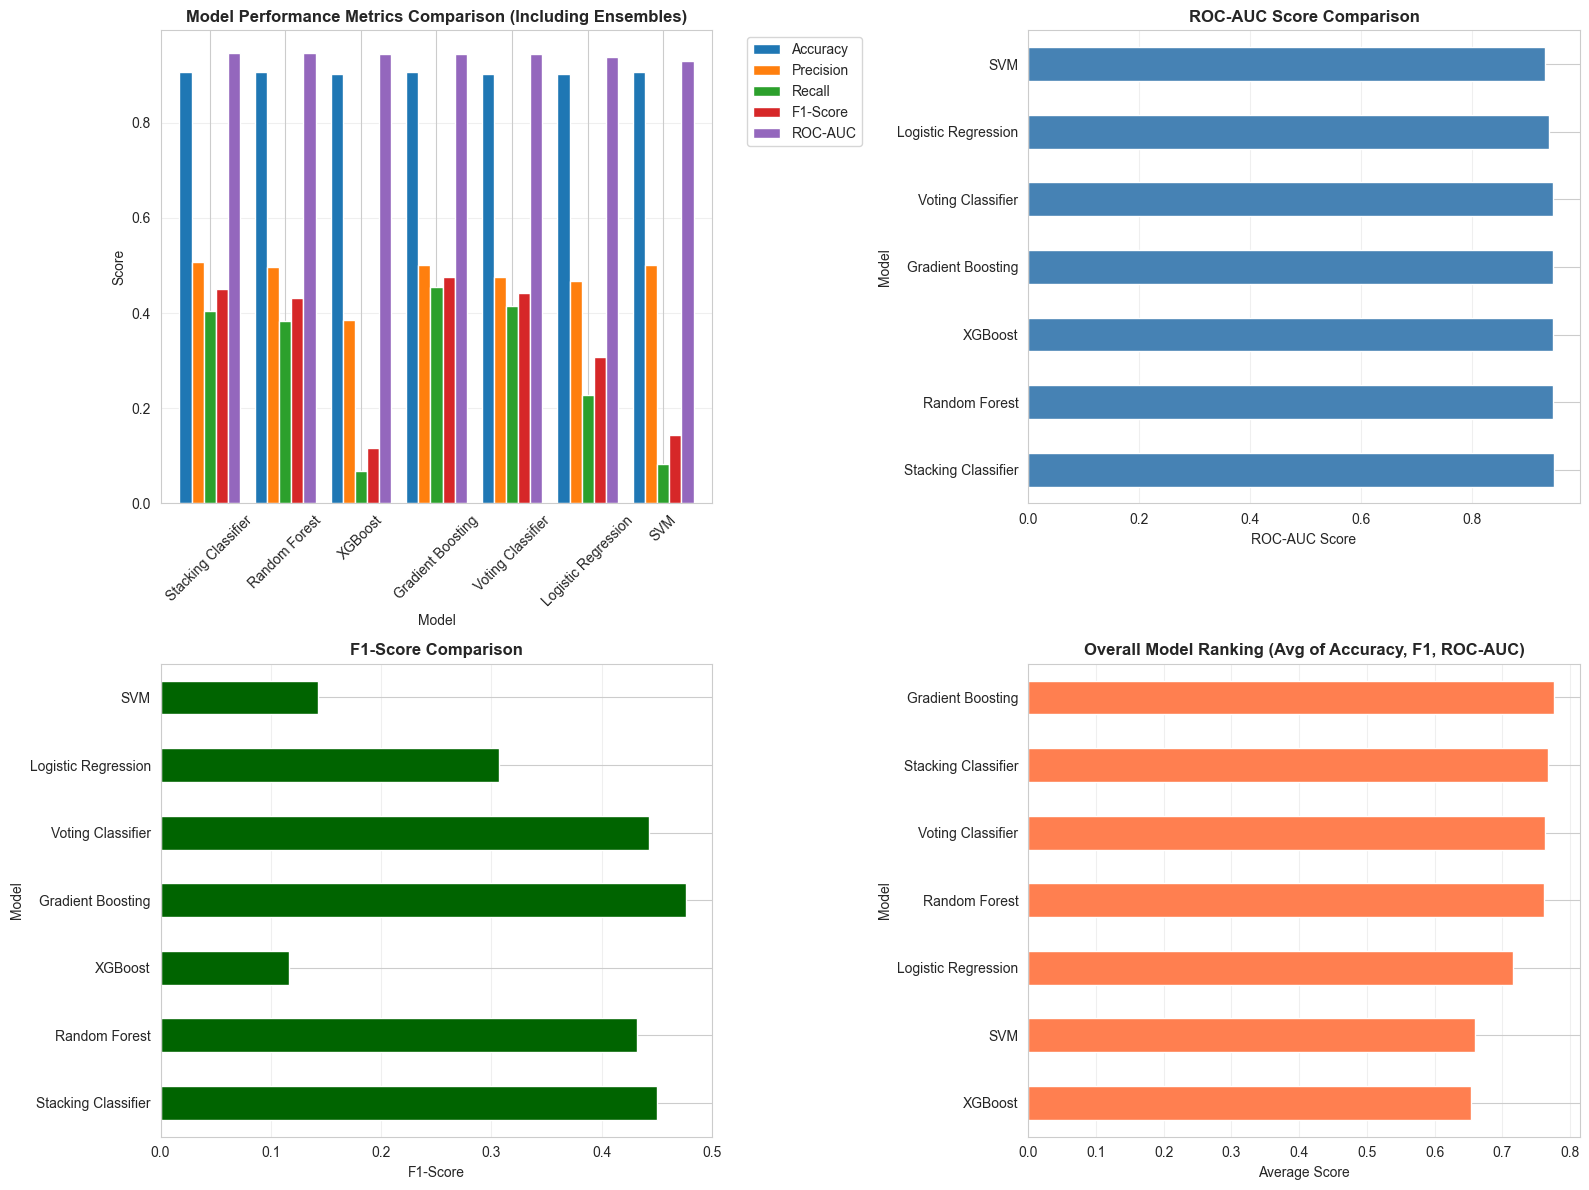

In [41]:
# Update results DataFrame with ensemble models
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("Updated Model Performance Comparison (Including Ensembles):")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize updated results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df[metrics].plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Model Performance Metrics Comparison (Including Ensembles)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=10)
axes[0, 0].set_xlabel('Model', fontsize=10)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# ROC-AUC comparison
results_df['ROC-AUC'].plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('ROC-AUC Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# F1-Score comparison
results_df['F1-Score'].plot(kind='barh', ax=axes[1, 0], color='darkgreen')
axes[1, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('F1-Score', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking
results_df['Overall Score'] = (
    results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']
) / 3
overall_score = results_df['Overall Score'].sort_values(ascending=True)
overall_score.plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Overall Model Ranking (Avg of Accuracy, F1, ROC-AUC)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

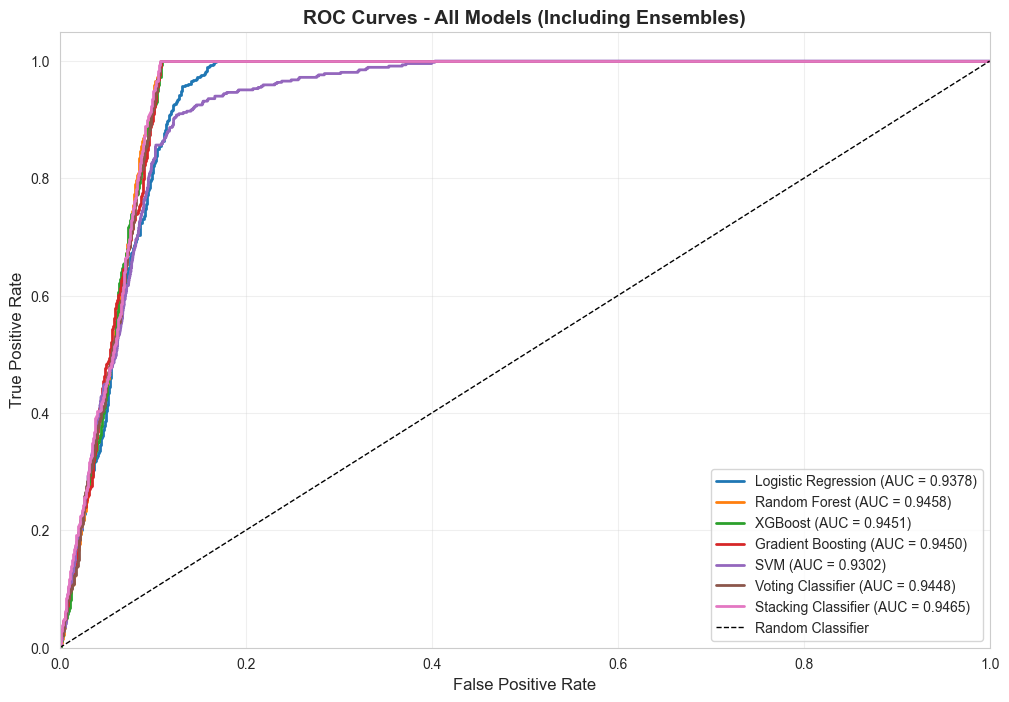

In [42]:
# Update ROC curves to include ensemble models
plt.figure(figsize=(12, 8))

for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Including Ensembles)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 11. Save Models

In [43]:
# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Create timestamp for model versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("Saving models...")
print("=" * 80)

# Save all individual models
saved_models = {}

for name, model in models.items():
    # Determine if model needs scaled features
    if name in ['Logistic Regression', 'SVM']:
        # Save model with scaler
        model_data = {
            'model': model,
            'scaler': scaler,
            'requires_scaling': True
        }
    else:
        model_data = {
            'model': model,
            'requires_scaling': False
        }
    
    filename = f"churn_model_{name.lower().replace(' ', '_')}_{timestamp}.pkl"
    filepath = models_dir / filename
    joblib.dump(model_data, filepath)
    saved_models[name] = filepath
    print(f"✓ Saved {name} to {filepath}")

# Save ensemble models
ensemble_models_to_save = {
    'Voting Classifier': voting_clf,
    'Stacking Classifier': stacking_clf
}

for name, model in ensemble_models_to_save.items():
    model_data = {
        'model': model,
        'requires_scaling': False
    }
    filename = f"churn_model_{name.lower().replace(' ', '_')}_{timestamp}.pkl"
    filepath = models_dir / filename
    joblib.dump(model_data, filepath)
    saved_models[name] = filepath
    print(f"✓ Saved {name} to {filepath}")

# Save the best model separately
best_model_name = results_df['Overall Score'].idxmax()
best_model = models.get(best_model_name) or ensemble_models_to_save.get(best_model_name)

if best_model:
    if best_model_name in ['Logistic Regression', 'SVM']:
        best_model_data = {
            'model': best_model,
            'scaler': scaler,
            'requires_scaling': True
        }
    else:
        best_model_data = {
            'model': best_model,
            'requires_scaling': False
        }
    
    best_model_path = models_dir / f"churn_model_best_{timestamp}.pkl"
    joblib.dump(best_model_data, best_model_path)
    print(f"\n⭐ Saved Best Model ({best_model_name}) to {best_model_path}")

print("\n" + "=" * 80)

Saving models...
✓ Saved Logistic Regression to models\churn_model_logistic_regression_20260214_192352.pkl
✓ Saved Random Forest to models\churn_model_random_forest_20260214_192352.pkl
✓ Saved XGBoost to models\churn_model_xgboost_20260214_192352.pkl
✓ Saved Gradient Boosting to models\churn_model_gradient_boosting_20260214_192352.pkl
✓ Saved SVM to models\churn_model_svm_20260214_192352.pkl
✓ Saved Voting Classifier to models\churn_model_voting_classifier_20260214_192352.pkl
✓ Saved Stacking Classifier to models\churn_model_stacking_classifier_20260214_192352.pkl

⭐ Saved Best Model (Gradient Boosting) to models\churn_model_best_20260214_192352.pkl



In [44]:
# Save preprocessing objects and metadata
preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': list(X.columns),
    'categorical_features': available_categorical,
    'numerical_features': available_numerical
}

preprocessing_path = models_dir / f"preprocessing_{timestamp}.pkl"
joblib.dump(preprocessing_data, preprocessing_path)
print(f"✓ Saved preprocessing objects to {preprocessing_path}")

# Save model performance results
results_summary = {
    'timestamp': timestamp,
    'results': results_df.to_dict(),
    'best_model': best_model_name,
    'test_size': len(y_test),
    'train_size': len(y_train),
    'churn_rate': float(y.mean())
}

results_path = models_dir / f"model_results_{timestamp}.pkl"
joblib.dump(results_summary, results_path)
print(f"✓ Saved model results to {results_path}")

# Also save results as CSV for easy viewing
results_csv_path = models_dir / f"model_results_{timestamp}.csv"
results_df.to_csv(results_csv_path)
print(f"✓ Saved model results (CSV) to {results_csv_path}")

print("\n" + "=" * 80)
print("All models and metadata saved successfully! 🎉")
print("=" * 80)

✓ Saved preprocessing objects to models\preprocessing_20260214_192352.pkl
✓ Saved model results to models\model_results_20260214_192352.pkl
✓ Saved model results (CSV) to models\model_results_20260214_192352.csv

All models and metadata saved successfully! 🎉


## 12. Model Loading Example

In [45]:
# Example: How to load and use a saved model
print("Model Loading Example:")
print("=" * 80)
print("""
# To load a saved model, use the following code:

# Load the model
model_data = joblib.load('models/churn_model_best_YYYYMMDD_HHMMSS.pkl')
loaded_model = model_data['model']
requires_scaling = model_data.get('requires_scaling', False)

# If the model requires scaling, also load the scaler
if requires_scaling:
    scaler = model_data['scaler']

# Load preprocessing objects
preprocessing = joblib.load('models/preprocessing_YYYYMMDD_HHMMSS.pkl')
label_encoders = preprocessing['label_encoders']
feature_names = preprocessing['feature_names']

# Prepare new data for prediction
# (Make sure to use the same features and preprocessing steps)

# Make predictions
if requires_scaling:
    X_new_scaled = scaler.transform(X_new)
    predictions = loaded_model.predict(X_new_scaled)
    probabilities = loaded_model.predict_proba(X_new_scaled)
else:
    predictions = loaded_model.predict(X_new)
    probabilities = loaded_model.predict_proba(X_new)
""")

print("\nSaved Models Summary:")
print("=" * 80)
for name, path in saved_models.items():
    print(f"  {name}: {path}")
print(f"\n  Best Model: {best_model_path}")
print(f"  Preprocessing: {preprocessing_path}")
print(f"  Results: {results_path}")
print(f"  Results (CSV): {results_csv_path}")

Model Loading Example:

# To load a saved model, use the following code:

# Load the model
model_data = joblib.load('models/churn_model_best_YYYYMMDD_HHMMSS.pkl')
loaded_model = model_data['model']
requires_scaling = model_data.get('requires_scaling', False)

# If the model requires scaling, also load the scaler
if requires_scaling:
    scaler = model_data['scaler']

# Load preprocessing objects
preprocessing = joblib.load('models/preprocessing_YYYYMMDD_HHMMSS.pkl')
label_encoders = preprocessing['label_encoders']
feature_names = preprocessing['feature_names']

# Prepare new data for prediction
# (Make sure to use the same features and preprocessing steps)

# Make predictions
if requires_scaling:
    X_new_scaled = scaler.transform(X_new)
    predictions = loaded_model.predict(X_new_scaled)
    probabilities = loaded_model.predict_proba(X_new_scaled)
else:
    predictions = loaded_model.predict(X_new)
    probabilities = loaded_model.predict_proba(X_new)


Saved Models Summary:
  Logis

In [46]:
# Final summary with ensemble models
print("=" * 80)
print("FINAL MODEL COMPARISON SUMMARY (Including Ensembles)")
print("=" * 80)

# Best model by each metric
best_accuracy = results_df['Accuracy'].idxmax()
best_f1 = results_df['F1-Score'].idxmax()
best_roc_auc = results_df['ROC-AUC'].idxmax()

print(f"\n🏆 Best Model by Accuracy: {best_accuracy} ({results_df.loc[best_accuracy, 'Accuracy']:.4f})")
print(f"🏆 Best Model by F1-Score: {best_f1} ({results_df.loc[best_f1, 'F1-Score']:.4f})")
print(f"🏆 Best Model by ROC-AUC: {best_roc_auc} ({results_df.loc[best_roc_auc, 'ROC-AUC']:.4f})")

# Overall best model
best_overall = results_df['Overall Score'].idxmax()

print(f"\n⭐ Overall Best Model: {best_overall}")
print(f"   Accuracy: {results_df.loc[best_overall, 'Accuracy']:.4f}")
print(f"   F1-Score: {results_df.loc[best_overall, 'F1-Score']:.4f}")
print(f"   ROC-AUC: {results_df.loc[best_overall, 'ROC-AUC']:.4f}")
print(f"   Overall Score: {results_df.loc[best_overall, 'Overall Score']:.4f}")

print(f"\n📁 All models saved to: {models_dir.absolute()}")
print(f"📊 Total models saved: {len(saved_models) + 1}")  # +1 for best model

print("\n" + "=" * 80)
print("Model Training and Saving Complete! 🎉")
print("=" * 80)

FINAL MODEL COMPARISON SUMMARY (Including Ensembles)

🏆 Best Model by Accuracy: Stacking Classifier (0.9071)
🏆 Best Model by F1-Score: Gradient Boosting (0.4765)
🏆 Best Model by ROC-AUC: Stacking Classifier (0.9465)

⭐ Overall Best Model: Gradient Boosting
   Accuracy: 0.9059
   F1-Score: 0.4765
   ROC-AUC: 0.9450
   Overall Score: 0.7758

📁 All models saved to: d:\Internship\Renewal-Upsell-Advisor\Research\models
📊 Total models saved: 8

Model Training and Saving Complete! 🎉
